In [1]:
import logging
from nlab_modbus.manager import DeviceManager
import time
import matplotlib.pyplot as plt


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    force=True
)
logging.getLogger("pymodbus").setLevel(logging.CRITICAL)
logging.getLogger("pymodbus.logging").setLevel(logging.CRITICAL)


In [2]:
mgr = DeviceManager()

In [3]:
ips = await mgr.scan_remote_ips_async()
print(ips)

['192.168.10.128', '192.168.10.134']


In [4]:
mgr.scan_local_ports()

2026-06-01 17:22:12,846 | INFO     | nlab_modbus.discovery.scan | Register found: 257


In [5]:
mgr.local

In [6]:
mgr.local[0].connection_info()

'serial://COM6:1'

In [7]:
mgr.local[0].get_board_temp()

29.51

In [8]:
for ip in ips:
    mgr.scan_remote(ip, [5001, 5002])

2026-06-01 17:22:18,765 | INFO     | nlab_modbus.discovery.scan | Register found: 769
2026-06-01 17:22:20,861 | INFO     | nlab_modbus.discovery.scan | Register found: 257
2026-06-01 17:22:20,891 | INFO     | nlab_modbus.discovery.scan | Register found: 513


In [9]:
mgr.remote

In [10]:
mgr.remote[0].set_pwm_enable(1)

In [11]:
mgr.all_devices

In [12]:
mgr.close_all()

In [13]:
mgr.local[0].connect()

In [14]:
temps = []
counts = []
times = []
t0 = time.monotonic()
dt = 0.22
next_time = t0 + dt  # Absolute target for first
while next_time - t0 < 15:
    temp = mgr.local[0].get_board_temp()
    cps = mgr.remote[2].get_pulses_per_sec()
    temps.append(temp)
    counts.append(cps)
    times.append(time.monotonic() - t0)
    print(f"{times[-1]:8.2f} s, {temp:7.2f} °C, {cps:6d} cps", end="\r")
    next_time += dt
    sleep_dur = next_time - time.monotonic()
    if sleep_dur > 0:
        time.sleep(sleep_dur)

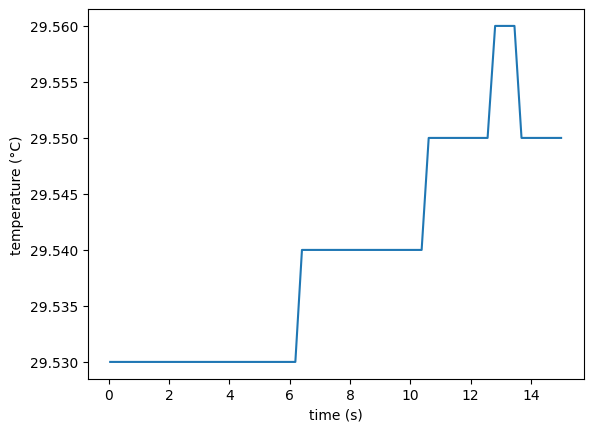

In [15]:
plt.figure()
plt.plot(times, temps)
plt.xlabel('time (s)')
plt.ylabel('temperature (°C)')
plt.show()

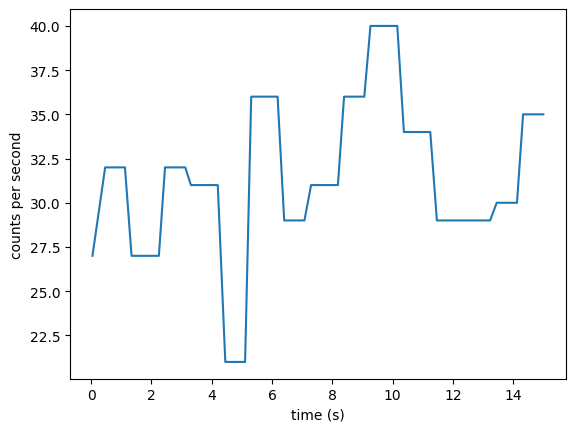

In [16]:
plt.figure()
plt.plot(times, counts)
plt.xlabel('time (s)')
plt.ylabel('counts per second')
plt.show()

In [17]:
import numpy as np

In [18]:
np.array(times[1:]) - np.array(times[:-1])

array([0.422, 0.234, 0.219, 0.203, 0.219, 0.218, 0.235, 0.219, 0.234,
       0.203, 0.234, 0.204, 0.234, 0.187, 0.25 , 0.219, 0.219, 0.203,
       0.25 , 0.203, 0.219, 0.234, 0.203, 0.235, 0.203, 0.219, 0.218,
       0.219, 0.235, 0.203, 0.234, 0.219, 0.219, 0.234, 0.203, 0.234,
       0.204, 0.218, 0.219, 0.234, 0.204, 0.218, 0.219, 0.234, 0.219,
       0.219, 0.234, 0.203, 0.235, 0.203, 0.219, 0.218, 0.235, 0.203,
       0.234, 0.203, 0.25 , 0.204, 0.218, 0.219, 0.234, 0.204, 0.234,
       0.203, 0.219, 0.219, 0.234])

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 13.,  5.,  0.,  0.,  0.,
         0.,  0.,  0.,  6., 18.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 15.,
         5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.187     , 0.18883594, 0.19067187, 0.19250781, 0.19434375,
        0.19617969, 0.19801562, 0.19985156, 0.2016875 , 0.20352344,
        0.20535937, 0.20719531, 0.20903125, 0.21086719, 0.21270312,
        0.21453906, 0.216375  , 0.21821094, 0.22004687, 0.22188281,
      

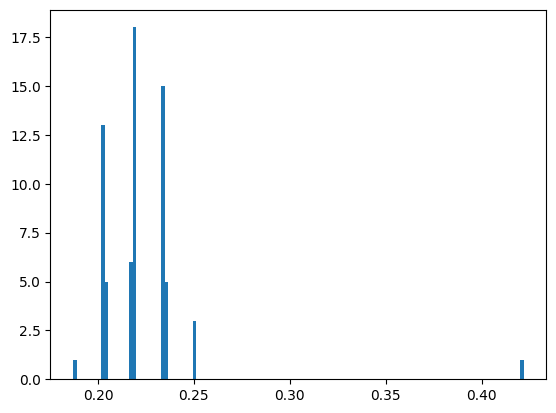

In [19]:
plt.hist(np.array(times[1:]) - np.array(times[:-1]), bins=128)

In [20]:
mgr.local[0]

In [21]:
result = mgr.local[0].read_snapshot()

In [22]:
print(result)

{'sipm_voltage_10mv': 0.31, 'sipm_current_ua': 0.0, 'board_temp_adc': 28.94, 'usb_rx_frames_cnt': 12747.0, 'usb_rx_crc_err_cnt': 5.0, 'usb_rx_bad_req_cnt': 8.0, 'cpu_temp': 33.0, 'board_temp': 29.55, 'eeprom_error': 0.0, 'supply_voltage': 4.92, 'adc_sipm_vout': 0.4, 'sipm_board_temp': -300.0, 'sipm_correct_voltage_mv': 0.0, 'vout_supply_fault': 0.0, 'ext_amp_supply_fault': 0.0, 'led_drv_temp': 30.0, 'led_drv_status': 0.0, 'vout_ripple': 5.0, 'pid_saturation': 0.0}


{'hardware_version': 257.0,
 'firmware_version': 2.0,
 'vout_overload': 1.0,
 'sipm_voltage_10mv': 0.31,
 'sipm_current_ua': 0.0,
 'board_temp_adc': 28.98,
 'usb_rx_frames_cnt': 12754.0,
 'usb_rx_crc_err_cnt': 5.0,
 'usb_rx_bad_req_cnt': 8.0,
 'cpu_temp': 33.0,
 'board_temp': 29.560000000000002,
 'eeprom_error': 0.0,
 'supply_voltage': 4.91,
 'adc_sipm_vout': 0.4,
 'sipm_board_temp': -300.0,
 'sipm_correct_voltage_mv': 0.0,
 'vout_supply_fault': 0.0,
 'ext_amp_supply_fault': 0.0,
 'led_drv_temp': 30.0,
 'led_drv_status': 0.0,
 'vout_ripple': 5.0,
 'pid_saturation': 0.0}

In [29]:
[[i, *pair] for i, pair in  enumerate(mgr.local[0].get_all_input_registers().items())]

[[0, 'hardware_version', 257.0],
 [1, 'firmware_version', 2.0],
 [2, 'vout_overload', 1.0],
 [3, 'sipm_voltage_10mv', 0.31],
 [4, 'sipm_current_ua', 0.0],
 [5, 'board_temp_adc', 29.02],
 [6, 'usb_rx_frames_cnt', 12864.0],
 [7, 'usb_rx_crc_err_cnt', 5.0],
 [8, 'usb_rx_bad_req_cnt', 8.0],
 [9, 'cpu_temp', 33.0],
 [10, 'board_temp', 29.6],
 [11, 'eeprom_error', 0.0],
 [12, 'supply_voltage', 4.91],
 [13, 'adc_sipm_vout', 0.42],
 [14, 'sipm_board_temp', -300.0],
 [15, 'sipm_correct_voltage_mv', 0.0],
 [16, 'vout_supply_fault', 0.0],
 [17, 'ext_amp_supply_fault', 0.0],
 [18, 'led_drv_temp', 30.0],
 [19, 'led_drv_status', 0.0],
 [20, 'vout_ripple', 6.0],
 [21, 'pid_saturation', 0.0]]

In [30]:
mgr.close_all()

In [35]:
mgr.local[0].device_type.name

'SIPM'